<a href="https://www.kaggle.com/code/sonawanelalitsunil/ev-population-trends-ml-100?scriptVersionId=250419485" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/electric-vehicle-population-analysis/EV_EDA_Report.html
/kaggle/input/electric-vehicle-population-analysis/Electric Vehicle Population Analysis.ipynb
/kaggle/input/electric-vehicle-population-analysis/Electric_Vehicle_Population_Data.csv
/kaggle/input/electric-vehicle-population-analysis/Electric Vehicle Population Analysis.py


## Title :
EV Population Trends

##  Description:
This analysis explores the growth and distribution of electric vehicles (EVs) over time and across regions. It examines key factors influencing EV adoption such as government policies, charging infrastructure, environmental impact, and consumer preferences. The goal is to understand patterns in EV population growth, identify leading markets, and forecast future trends in sustainable transportation.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/electric-vehicle-population-analysis/Electric_Vehicle_Population_Data.csv')

In [3]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4BZ0CP5G,King,Seattle,WA,98125.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,349455557,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,KNDJX3AEXG,King,Renton,WA,98058.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,11.0,210641315,POINT (-122.08747 47.4466),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
2,5YJ3E1EB2J,King,Seattle,WA,98115.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,43.0,171417494,POINT (-122.31676 47.68156),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,1C4RJXN64R,Kitsap,Bremerton,WA,98312.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,26.0,262542927,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB1J,Thurston,Olympia,WA,98512.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,35.0,110432815,POINT (-122.9131 47.01359),PUGET SOUND ENERGY INC,5.306701e+10


In [4]:
df.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
247339,7G2CEHED0R,King,Newcastle,WA,98056.0,2024,TESLA,CYBERTRUCK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,41.0,278417947,POINT (-122.1805 47.50006),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
247340,1C4RJYC65R,Pierce,Puyallup,WA,98374.0,2024,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,0.0,25.0,271451197,POINT (-122.27575 47.13959),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
247341,7SAYGDEE0P,King,Bothell,WA,98011.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,249563667,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
247342,KNDPYDAH9P,Kitsap,Bainbridge Island,WA,98110.0,2023,KIA,SPORTAGE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,34.0,0.0,23.0,238968376,POINT (-122.521 47.62728),PUGET SOUND ENERGY INC,5.303509e+10
247343,KNDPZDAH8P,Whatcom,Bellingham,WA,98226.0,2023,KIA,SPORTAGE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,34.0,0.0,42.0,253768637,POINT (-122.49756 48.7999),PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,5.307300e+10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247344 entries, 0 to 247343
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         247344 non-null  object 
 1   County                                             247340 non-null  object 
 2   City                                               247340 non-null  object 
 3   State                                              247344 non-null  object 
 4   Postal Code                                        247340 non-null  float64
 5   Model Year                                         247344 non-null  int64  
 6   Make                                               247344 non-null  object 
 7   Model                                              247344 non-null  object 
 8   Electric Vehicle Type                              247344 non-null  object

In [6]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,247340.000000,247344.000000,247324.000000,247324.000000,246791.000000,2.473440e+05,2.473400e+05
mean,98180.773999,2021.572450,44.645659,740.206308,29.039924,2.382157e+08,5.297516e+10
std,2496.155753,3.014246,82.945315,6971.140984,14.857603,6.709585e+07,1.606887e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,18.000000,2.089133e+08,5.303301e+10
50%,98125.000000,2023.000000,0.000000,0.000000,33.000000,2.560989e+08,5.303303e+10
75%,98382.000000,2024.000000,37.000000,0.000000,42.000000,2.723745e+08,5.305307e+10
max,99577.000000,2026.000000,337.000000,845000.000000,49.000000,4.792548e+08,6.601095e+10


In [7]:
df.dtypes

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract       

In [8]:
df.shape

(247344, 17)

In [9]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 4
City                                                   4
State                                                  0
Postal Code                                            4
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        20
Base MSRP                                             20
Legislative District                                 553
DOL Vehicle ID                                         0
Vehicle Location                                      11
Electric Utility                                       4
2020 Census Tract                                      4
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

## Data visualizations

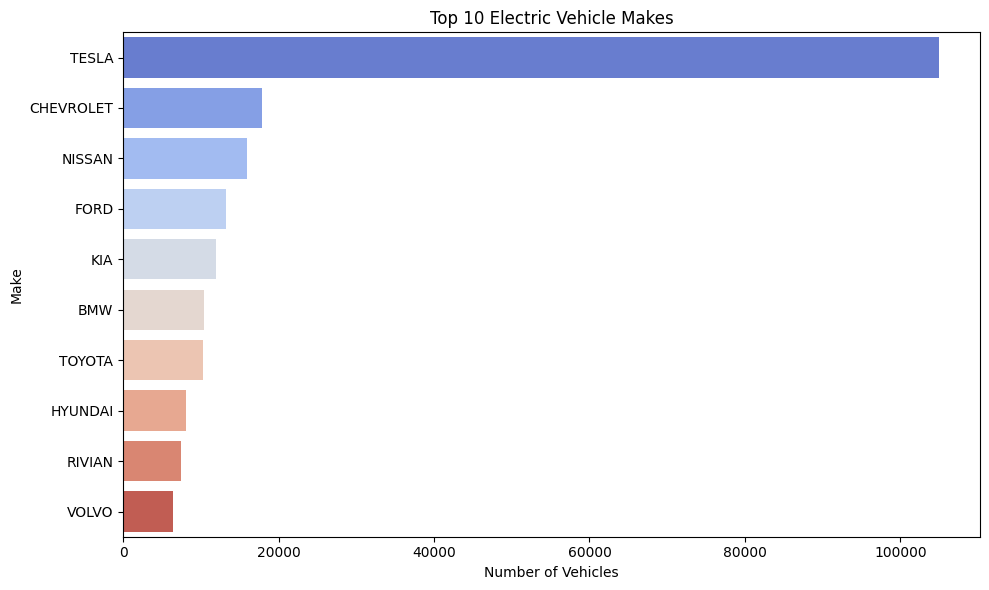

In [12]:
plt.figure(figsize=(10,6))
top_makes = df['Make'].value_counts().nlargest(10)
sns.barplot(x=top_makes.values, y=top_makes.index, palette='coolwarm')
plt.title('Top 10 Electric Vehicle Makes')
plt.xlabel('Number of Vehicles')
plt.ylabel('Make')
plt.tight_layout()
plt.show()


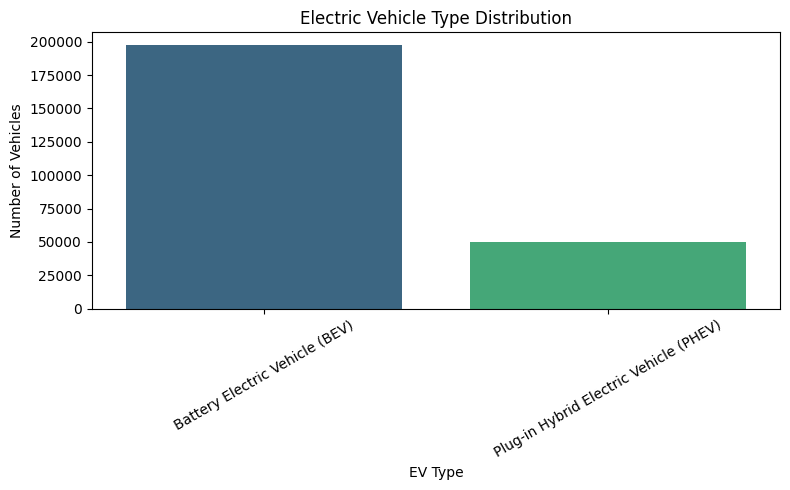

In [13]:
plt.figure(figsize=(8,5))
ev_type_counts = df['Electric Vehicle Type'].value_counts()
sns.barplot(x=ev_type_counts.index, y=ev_type_counts.values, palette='viridis')
plt.title('Electric Vehicle Type Distribution')
plt.ylabel('Number of Vehicles')
plt.xlabel('EV Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


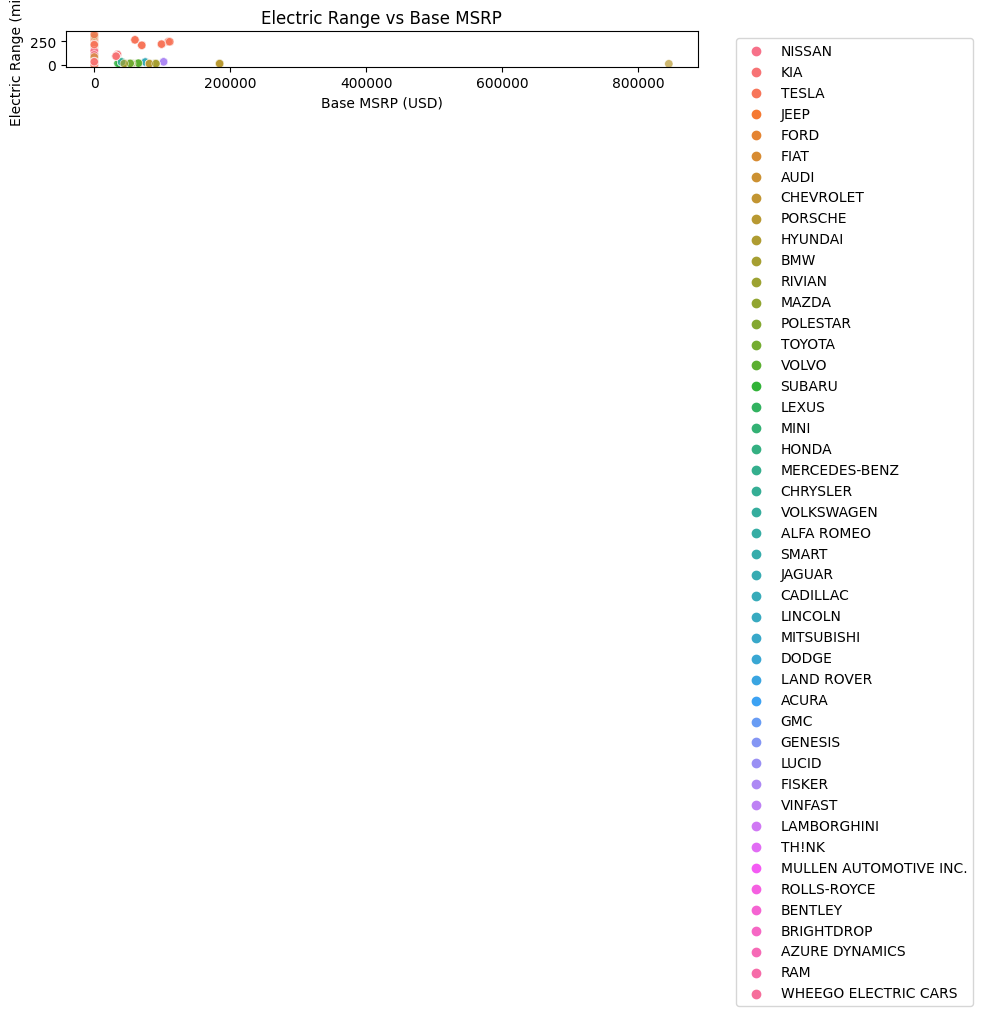

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Base MSRP', y='Electric Range', hue='Make', alpha=0.7)
plt.title('Electric Range vs Base MSRP')
plt.xlabel('Base MSRP (USD)')
plt.ylabel('Electric Range (miles)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()


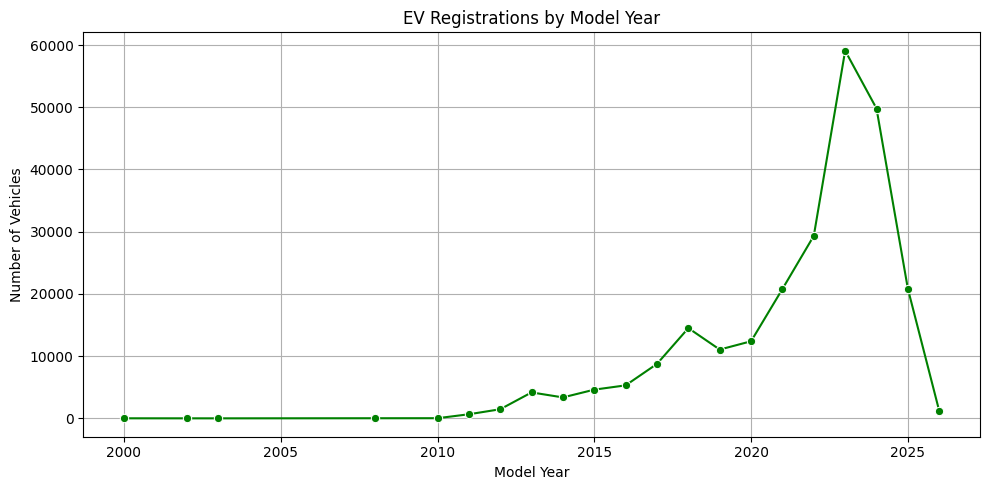

In [15]:
plt.figure(figsize=(10,5))
year_counts = df['Model Year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('EV Registrations by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles')
plt.grid(True)
plt.tight_layout()
plt.show()


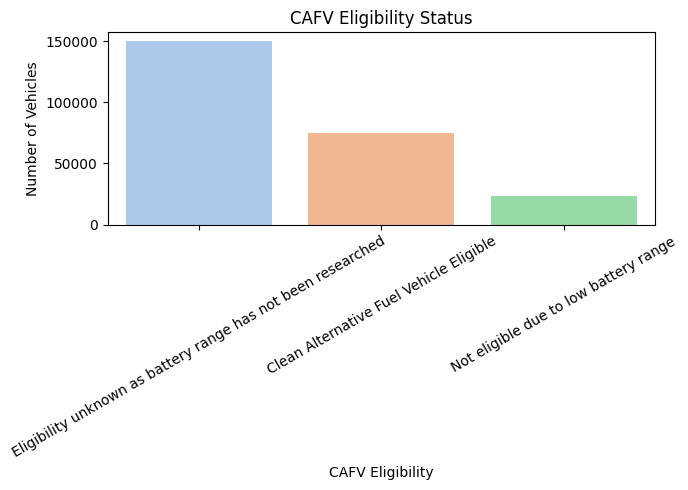

In [16]:
plt.figure(figsize=(7,5))
cafv_counts = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
sns.barplot(x=cafv_counts.index, y=cafv_counts.values, palette='pastel')
plt.title('CAFV Eligibility Status')
plt.ylabel('Number of Vehicles')
plt.xlabel('CAFV Eligibility')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


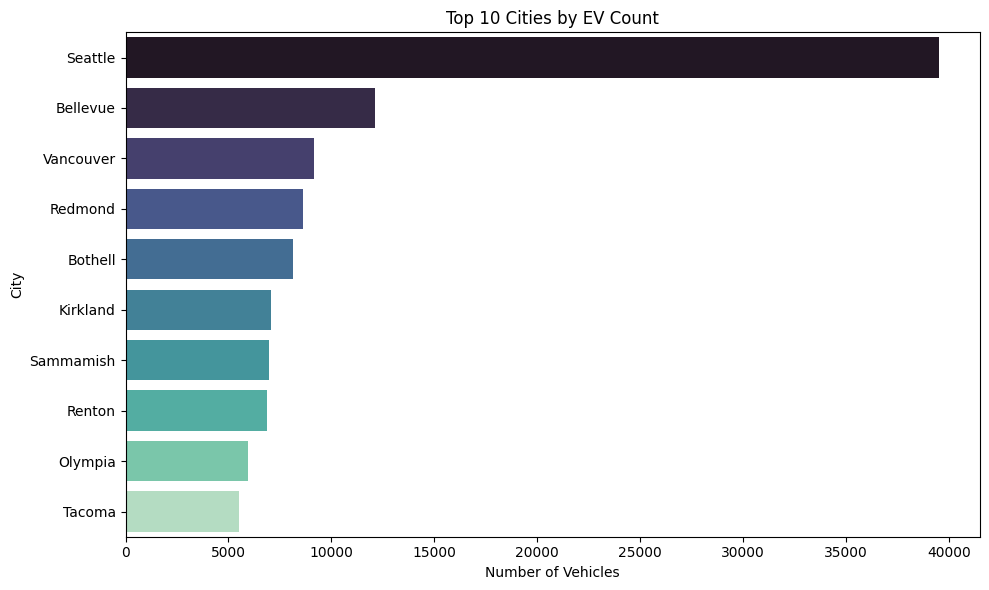

In [17]:
plt.figure(figsize=(10,6))
top_cities = df['City'].value_counts().nlargest(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette='mako')
plt.title('Top 10 Cities by EV Count')
plt.xlabel('Number of Vehicles')
plt.ylabel('City')
plt.tight_layout()
plt.show()


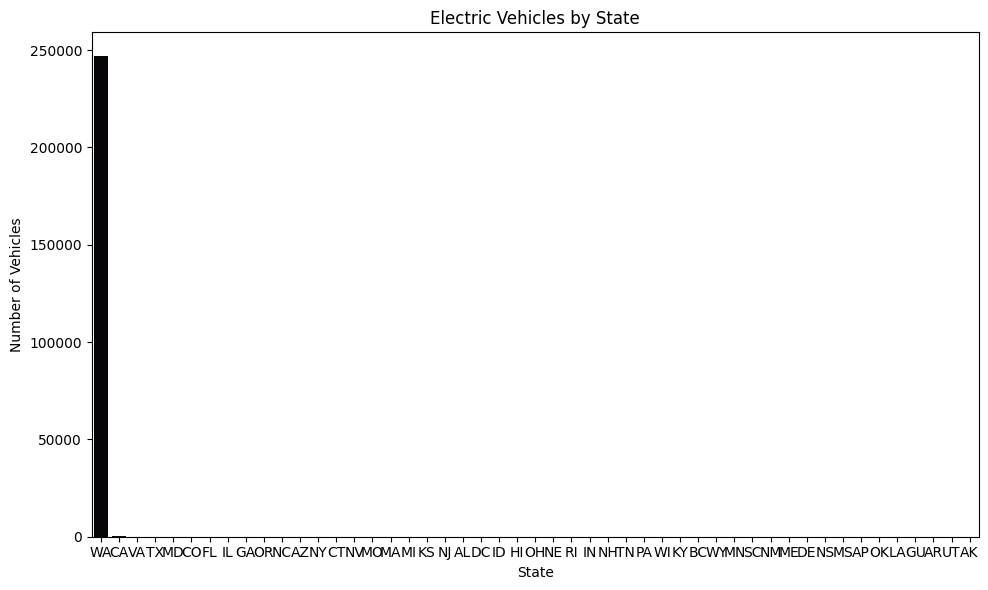

In [18]:
plt.figure(figsize=(10,6))
state_counts = df['State'].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values, palette='cubehelix')
plt.title('Electric Vehicles by State')
plt.xlabel('State')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()


## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [20]:
# Drop columns that are not useful or too unique (e.g., VIN, Vehicle ID, Location)
df.drop(columns=['VIN (1-10)', 'DOL Vehicle ID', 'Vehicle Location'], inplace=True)

# Fill or drop missing values (basic approach)
df = df.dropna()

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df.drop(columns=['Electric Vehicle Type'])  # features
y = df['Electric Vehicle Type']                 # target


In [21]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds) * 100  # convert to percentage
    accuracy_results[name] = accuracy


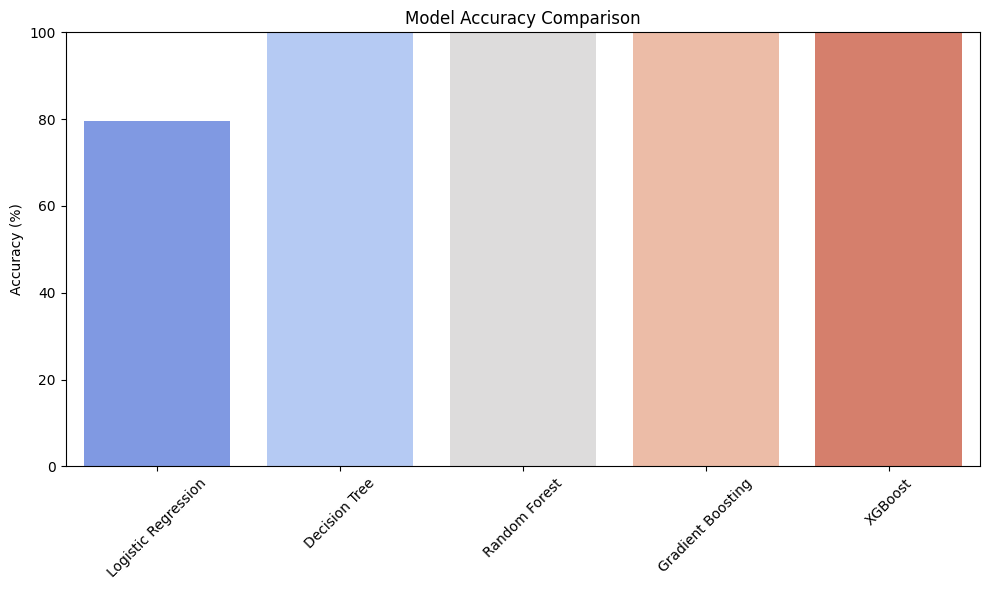

Logistic Regression: 79.58% accuracy
Decision Tree: 99.99% accuracy
Random Forest: 99.99% accuracy
Gradient Boosting: 99.99% accuracy
XGBoost: 100.00% accuracy


In [22]:
# Plot accuracy
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette='coolwarm')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Print accuracy values
for model, acc in accuracy_results.items():
    print(f'{model}: {acc:.2f}% accuracy')

## Thank you..pls upvote!!!